## Import Libraries

In [164]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder,StandardScaler,PolynomialFeatures
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
df = pd.read_csv(r"C:\Users\hp\Downloads\HouseingData.csv")

In [165]:
df.head()

,Property_ID,Property_Type,Property_Area,Number_of_Windows,Number_of_Doors,Furnishing,Frequency_of_Powercuts,Power_Backup,Water_Supply,Traffic_Density_Score,Crime_Rate,Dust_and_Noise,Air_Quality_Index,Neighborhood_Review,Habitability_score
0,0x21e3,Apartment,106,NaN,1,Semi_Furnished,0.0,No,Once in a day - Morning,5.89,Slightly below average,Medium,90.0,3.86,71.98
1,0x68d4,Apartment,733,2.0,2,Unfurnished,1.0,No,Once in a day - Evening,4.37,Well below average,Medium,96.0,3.55,71.20
2,0x7d81,Apartment,737,4.0,2,Fully Furnished,0.0,No,Once in a day - Morning,7.45,Slightly below average,Medium,121.0,3.81,71.39
3,0x7a57,Apartment,900,3.0,2,Unfurnished,2.0,Yes,Once in a day - Morning,6.16,Well above average,Medium,100.0,1.34,31.46
4,0x9409,Bungalow,2238,14.0,6,Fully Furnished,0.0,No,All time,5.46,Well below average,Medium,116.0,4.77,93.70


In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39499 entries, 0 to 39498
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Property_ID             39499 non-null  object 
 1   Property_Type           39499 non-null  object 
 2   Property_Area           39499 non-null  int64  
 3   Number_of_Windows       37845 non-null  float64
 4   Number_of_Doors         39499 non-null  int64  
 5   Furnishing              38457 non-null  object 
 6   Frequency_of_Powercuts  38116 non-null  float64
 7   Power_Backup            39499 non-null  object 
 8   Water_Supply            39499 non-null  object 
 9   Traffic_Density_Score   39499 non-null  float64
 10  Crime_Rate              38712 non-null  object 
 11  Dust_and_Noise          38280 non-null  object 
 12  Air_Quality_Index       39499 non-null  float64
 13  Neighborhood_Review     39499 non-null  float64
 14  Habitability_score      39499 non-null

In [167]:
df.isnull().sum()/(df.shape[0])*100

Property_ID               0.000000
Property_Type             0.000000
Property_Area             0.000000
Number_of_Windows         4.187448
Number_of_Doors           0.000000
Furnishing                2.638041
Frequency_of_Powercuts    3.501354
Power_Backup              0.000000
Water_Supply              0.000000
Traffic_Density_Score     0.000000
Crime_Rate                1.992456
Dust_and_Noise            3.086154
Air_Quality_Index         0.000000
Neighborhood_Review       0.000000
Habitability_score        0.000000
dtype: float64

In [168]:
df.duplicated().sum()

np.int64(0)

Text(0.5, 1.0, 'Outlier')

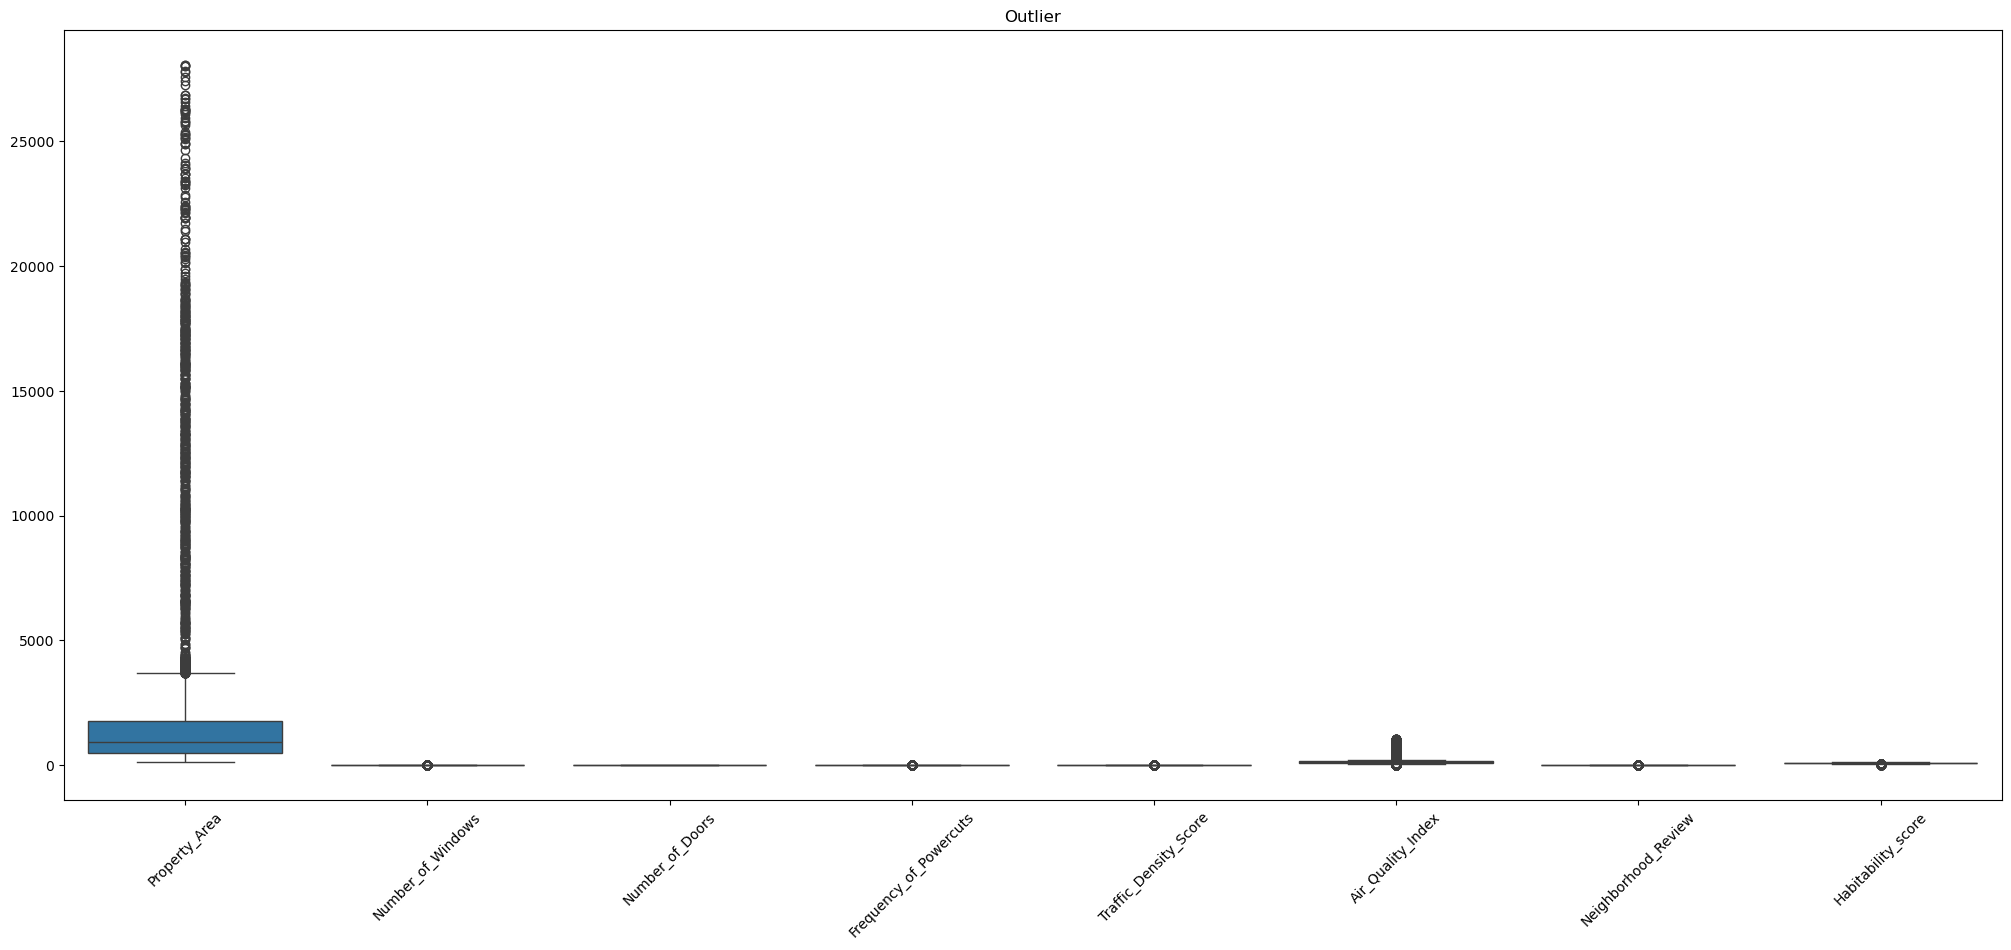

In [169]:
data=df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(25,10))
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.title("Outlier")

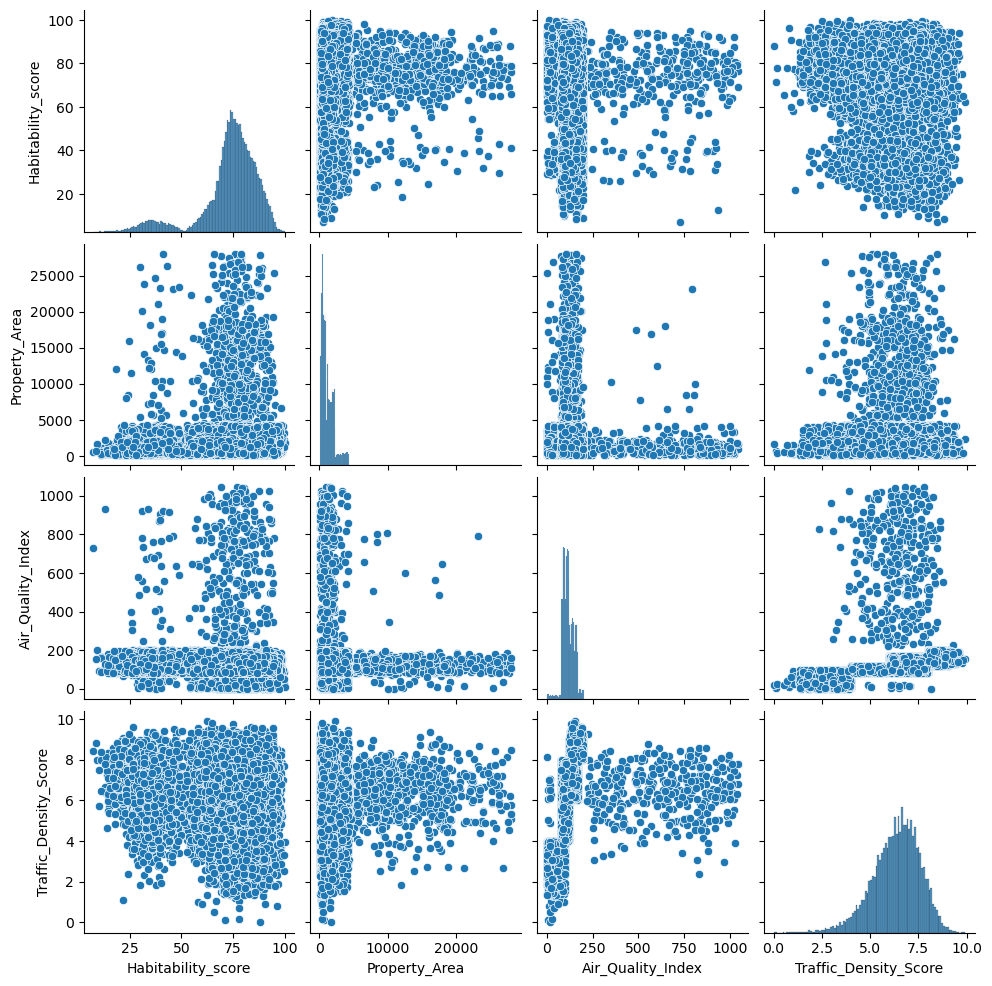

In [170]:
data=df[['Habitability_score','Property_Area','Air_Quality_Index','Traffic_Density_Score']]
sns.pairplot(data)

In [201]:
cor=df.corr(numeric_only=True)[['Habitability_score']].sort_values(by='Habitability_score',ascending=False)
cor

,Habitability_score
Habitability_score,1.000000
Neighborhood_Review,0.540033
Number_of_Windows,0.094640
Number_of_Doors,0.072108
Property_Area,0.065079
Air_Quality_Index,-0.042233
Traffic_Density_Score,-0.070289
Frequency_of_Powercuts,-0.234487


<Axes: >

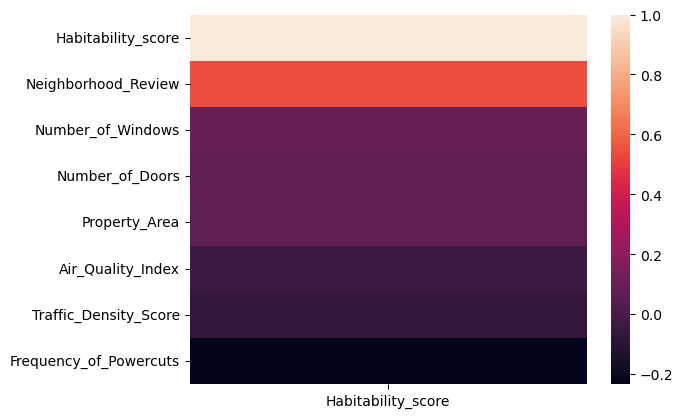

In [202]:
sns.heatmap(cor)

In [172]:
x=df.drop(columns = ["Property_ID","Habitability_score"])
y = df["Habitability_score"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.21, random_state = 41)

In [173]:
df['Property_Type'] = df['Property_Type'].replace('#R%$G&867','other')

## Handling Outliers

In [174]:

col = x_train.select_dtypes(include=np.number).columns
train_outlier=set()

for c in col:
    q1=x_train[c].quantile(0.25)
    q3=x_train[c].quantile(0.75)
    iqr = q3 - q1
    l1 = q1 - 1.5*iqr
    r1 = q3 + 1.5*iqr
    outlier = x_train[ (x_train[c]<l1) | (x_train[c]>r1) ].index
    train_outlier.update(outlier)
    x_test[c]=np.clip(x_test[c],l1,r1)
x_train = x_train.drop(index=train_outlier)
y_train = y_train.drop(index=train_outlier)


## Imputation

In [175]:


si1 = SimpleImputer(strategy = 'most_frequent')
si2 = SimpleImputer(strategy = 'most_frequent')
si3 = SimpleImputer(strategy = 'most_frequent')
si4 = SimpleImputer(strategy = 'mean')
si5 = SimpleImputer(strategy = 'mean')

x_train[['Furnishing']] = si1.fit_transform(x_train[['Furnishing']])
x_test[['Furnishing']] = si1.transform(x_test[['Furnishing']])

x_train[['Crime_Rate']] = si2.fit_transform(x_train[['Crime_Rate']])
x_test[['Crime_Rate']] = si2.transform(x_test[['Crime_Rate']])

x_train[['Dust_and_Noise']] = si3.fit_transform(x_train[['Dust_and_Noise']])
x_test[['Dust_and_Noise']] = si3.transform(x_test[['Dust_and_Noise']])

x_train[['Number_of_Windows']] = si4.fit_transform(x_train[['Number_of_Windows']])
x_test[['Number_of_Windows']] = si4.transform(x_test[['Number_of_Windows']])

x_train[['Frequency_of_Powercuts']] = si5.fit_transform(x_train[['Frequency_of_Powercuts']])
x_test[['Frequency_of_Powercuts']] = si5.transform(x_test[['Frequency_of_Powercuts']])

## Encoding

In [176]:

oe1 = OrdinalEncoder()
oe2 = OrdinalEncoder()
oe3 = OrdinalEncoder()
oe4 = OrdinalEncoder()
le = LabelEncoder()
ohe=OneHotEncoder(handle_unknown = 'ignore',sparse_output = False)

x_train[["Furnishing"]] = oe1.fit_transform(x_train[["Furnishing"]])
x_test[["Furnishing"]] = oe1.transform(x_test[["Furnishing"]])
                                     
x_train[["Water_Supply"]] = oe2.fit_transform(x_train[["Water_Supply"]])
x_test[["Water_Supply"]] = oe2.transform(x_test[["Water_Supply"]])

encoded_Property = ohe.fit_transform(x_train[['Property_Type']])
encoded_Property_test= ohe.transform(x_test[['Property_Type']])

encoded_Property = pd.DataFrame(encoded_Property,columns = ohe.get_feature_names_out(['Property_Type']),index = x_train.index)
encoded_Property_test = pd.DataFrame(encoded_Property_test,columns = ohe.get_feature_names_out(['Property_Type']),index = x_test.index)

x_train = pd.concat([x_train.drop('Property_Type',axis = 1),encoded_Property],axis = 1)
x_test = pd.concat([x_test.drop('Property_Type',axis = 1),encoded_Property_test],axis=1)
                                
                                
x_train["Power_Backup"]=le.fit_transform(x_train["Power_Backup"])
x_test["Power_Backup"]=le.transform(x_test["Power_Backup"])

x_train[['Crime_Rate']] = oe3.fit_transform(x_train[['Crime_Rate']])
x_test[['Crime_Rate']] = oe3.transform(x_test[['Crime_Rate']])

x_train[['Dust_and_Noise']] = oe4.fit_transform(x_train[['Dust_and_Noise']])
x_test[['Dust_and_Noise']] = oe4.transform(x_test[['Dust_and_Noise']])



## Scaling

In [177]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


## LinearRegression

In [178]:
lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)


In [180]:
print("Linear Regression")
print(f" R^2 Score : {r2_score(y_test,y_pred):.4f}")
print(f" MSE : {mean_squared_error(y_test,y_pred):.4f}")
print(f" MAE : {mean_absolute_error(y_test,y_pred):.4f}")
print(f" RMSE : {np.sqrt(mean_squared_error(y_test,y_pred)):.4f}")

Linear Regression
 R^2 Score : 0.5606
 MSE : 90.1394
 MAE : 7.4731
 RMSE : 9.4942


In [181]:
print(f"test_score : {lr.score(x_test,y_test)*100:.2f}")
print(f"train_score : {lr.score(x_train,y_train)*100:.2f}")


test_score : 56.06
train_score : 53.97


## RidgeRegression

In [183]:
ri=Ridge(alpha=1.0)
ri.fit(x_train,y_train)
r_pred = ri.predict(x_test)

In [186]:
print("RidgeRegression")
print(f" R^2 Score : {r2_score(y_test,r_pred):.4f}")
print(f" MSE : {mean_squared_error(y_test,r_pred):.4f}")
print(f" MAE : {mean_absolute_error(y_test,r_pred):.4f}")
print(f" RMSE : {np.sqrt(mean_squared_error(y_test,r_pred)):.4f}")

RidgeRegression
 R^2 Score : 0.5606
 MSE : 90.1398
 MAE : 7.4731
 RMSE : 9.4942


In [187]:
print(f"test_score : {ri.score(x_test,y_test)*100:.2f}")
print(f"train_score : {ri.score(x_train,y_train)*100:.2f}")

test_score : 56.06
train_score : 53.97


## LassoRegression

In [188]:
l1=Lasso(alpha=.10)
l1.fit(x_train,y_train)
l1_pred = l1.predict(x_test)

In [189]:
print(f" R^2 Score : {r2_score(y_test,l1_pred):.4f}")
print(f" MSE : {mean_squared_error(y_test,l1_pred):.4f}")
print(f" MAE : {mean_absolute_error(y_test,l1_pred):.4f}")
print(f" RMSE : {np.sqrt(mean_squared_error(y_test,l1_pred)):.4f}")

 R^2 Score : 0.5587
 MSE : 90.5443
 MAE : 7.4451
 RMSE : 9.5155


In [190]:
print(f"test_score : {l1.score(x_test,y_test)*100:.2f}")
print(f"train_score : {l1.score(x_train,y_train)*100:.2f}")

test_score : 55.87
train_score : 53.83


## PolynomialRegression

In [193]:
poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)
pr=LinearRegression()
pr.fit(x_train_poly,y_train)
y_p = pr.predict(x_test_poly)
r2_score(y_test,y_p)

0.6980486941426156

In [194]:
print(f" R^2 Score : {r2_score(y_test,y_p):.4f}")
print(f" MSE : {mean_squared_error(y_test,y_p):.4f}")
print(f" MAE : {mean_absolute_error(y_test,y_p):.4f}")
print(f" RMSE : {np.sqrt(mean_squared_error(y_test,y_p)):.4f}")

 R^2 Score : 0.6980
 MSE : 61.9480
 MAE : 6.4545
 RMSE : 7.8707


In [195]:
print(f"test_score : {pr.score(x_test_poly,y_test)*100:.2f}")
print(f"train_score : {pr.score(x_train_poly,y_train)*100:.2f}")

test_score : 69.80
train_score : 67.87
